In [1]:
import sys, os, random, gc, contextlib, io, tempfile, shutil
from concurrent.futures import ProcessPoolExecutor, as_completed
from itertools import product as iproduct

# Ensure src/ is importable when running from notebooks-rework/
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

# Unified Planning: PDDL parsing, planning, and simulation
from unified_planning.shortcuts import *
from unified_planning.io import PDDLReader
import unified_planning
get_environment().credits_stream = None

# ASCAL: Learner class + helpers for demo generation
from ascal import Learner
from ascal.models import Literal, State, Action, Demonstration
from ascal import build_literal_descriptors, state_to_signature

# ASCAL Evaluation — Learner Class

This notebook evaluates the ASCAL (Version Space Learning of Action Models) algorithm using the `Learner` class from `ascal.learner`.

**Pipeline:**
1. Parse PDDL domain & problems → generate lifted positive/negative demonstrations in parallel
2. Split into training/testing sets (50/50) with a fixed random seed
3. Initialize `Learner`, feed one positive demo per action, then interleave remaining positives with negatives
4. At each snapshot (after every positive demo), evaluate Precision/Recall/F1 for the **sound** (L-boundary) and **complete** (U-boundary) models
5. Plot learning curves, save results to CSV, and inspect version space boundaries

**Key guarantees:**
- Sound model precision = 1.0 (never predicts an incorrect action application)
- Complete model recall = 1.0 (never misses a correct action application)

### Configuration
Choose domain, negative-to-positive ratio, and domain file below.

> **Note on domain files:**
> - `domain.pddl` — FAMA-style domain with 3 parameters per action + inequality constraints. Generates far more unique lifted demos, enabling full convergence.
> - `domain_original.pddl` — Original domain with natural parameter counts. Fewer unique lifted demos; version space may not fully converge.

In [2]:
# ── Experiment parameters ──────────────────────────────────────────────────────
DOMAIN_NAME      = "blocks"  # blocks, driverlog, miconic, satellite
RATIO_NEG_POS    = 5         # how many negative demos per positive demo
TRAIN_TEST_RATIO = 0.5       # fraction of demos used for training (rest → testing)
RANDOM_SEED      = 12345     # reproducibility seed for shuffling
MAX_WORKERS      = 4         # number of parallel processes for demo generation

# ── Paths ─────────────────────────────────────────────────────────────────────
BENCH_DIR    = os.path.abspath(f"../benchmarks/{DOMAIN_NAME}")
DOMAIN_FILE  = os.path.join(BENCH_DIR, "domain_extended.pddl")
PROBLEMS_DIR = os.path.join(BENCH_DIR, "problems")

print(f"Domain: {DOMAIN_NAME}  |  Ratio: {RATIO_NEG_POS}  |  Workers: {MAX_WORKERS}")
print(f"Domain file: {os.path.basename(DOMAIN_FILE)}")

Domain: blocks  |  Ratio: 5  |  Workers: 4
Domain file: domain_extended.pddl


### Demonstration Generation

Lifted demonstration generator that processes each PDDL problem file:
- **Positive demos:** For each plan step, record the lifted pre-state, action, and post-state.
- **Negative demos:** For each plan step, record all non-applicable action groundings as failures (pre-state + action, no post-state).

States are lifted by mapping ground object names to the action's parameter names (e.g., `block1` → `x`), keeping only literals whose arguments are a subset of the action's parameters.

In [3]:
def _load_demos_from_problem(problem):
    """Generate lifted demonstrations from a single PDDL problem."""
    all_literals = list(problem.initial_values.keys())
    all_objects  = list(problem.all_objects)
    literal_desc = build_literal_descriptors(all_literals)
    action_pars_dict = {a.name: tuple(par.name for par in a.parameters)
                        for a in problem.actions}

    action_groundings = {}
    for a in problem.actions:
        matching = [
            [o for o in all_objects if o.type.is_subtype(a.parameters[i].type)]
            for i in range(len(a.parameters))
        ]
        action_groundings[a] = [
            args for args in iproduct(*matching)
            if len(set(args)) == len(args)
        ]

    with OneshotPlanner(problem_kind=problem.kind) as planner:
        result = planner.solve(problem)
        if result.status != unified_planning.engines.PlanGenerationResultStatus.SOLVED_SATISFICING:
            return set(), set()

    def _lift_sig(signature, arg_names, map_a2p):
        action_args_set = set(arg_names)
        lifted = set()
        for name, args, val in signature:
            if set(args).issubset(action_args_set) and len(set(args)) == len(args):
                lifted.add(Literal(name, tuple(map_a2p[a] for a in args), val))
        return State(frozenset(lifted))

    pos_set = set()
    neg_set = set()

    with SequentialSimulator(problem=problem) as simulator:
        pre_state = simulator.get_initial_state()

        for action_instance in result.plan.actions:
            pre_sig = state_to_signature(pre_state, literal_desc)

            for a, valid_args in action_groundings.items():
                action_pars = action_pars_dict[a.name]
                for args in valid_args:
                    if not simulator.is_applicable(pre_state, a, args):
                        arg_names = tuple(o.name for o in args)
                        map_a2p = {arg_names[i]: action_pars[i]
                                   for i in range(len(arg_names))}
                        neg_set.add(Demonstration(
                            pre_state  = _lift_sig(pre_sig, arg_names, map_a2p),
                            action     = Action(a.name, action_pars),
                            post_state = None,
                        ))

            ascal_action = action_instance.action
            orig_args = tuple(par.object()
                              for par in action_instance.actual_parameters)
            post_state = simulator.apply(pre_state, action_instance)
            if post_state is None:
                break

            post_sig    = state_to_signature(post_state, literal_desc)
            arg_names   = tuple(o.name for o in orig_args)
            action_pars = action_pars_dict[ascal_action.name]
            map_a2p     = {arg_names[i]: action_pars[i]
                           for i in range(len(arg_names))}

            pos_set.add(Demonstration(
                pre_state  = _lift_sig(pre_sig, arg_names, map_a2p),
                action     = Action(ascal_action.name, action_pars),
                post_state = _lift_sig(post_sig, arg_names, map_a2p),
            ))
            pre_state = post_state

    return pos_set, neg_set


def _load_demos_for_file(problem_file):
    """Wrapper for parallel execution."""
    tmpdir = tempfile.mkdtemp(prefix="ascal_worker_")
    orig_cwd = os.getcwd()
    os.chdir(tmpdir)
    try:
        get_environment().credits_stream = None
        reader = PDDLReader()
        problem = reader.parse_problem(DOMAIN_FILE, os.path.join(PROBLEMS_DIR, problem_file))
        with contextlib.redirect_stdout(io.StringIO()):
            p, n = _load_demos_from_problem(problem)
        return p, n
    finally:
        os.chdir(orig_cwd)
        shutil.rmtree(tmpdir, ignore_errors=True)

### Generate Demonstrations (Parallel)
Each problem file is solved and simulated in a separate process. Demonstrations are deduplicated via set union across all problems.

In [4]:
%%time
problems = sorted(os.listdir(PROBLEMS_DIR))
all_pos = set()
all_neg = set()

with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(_load_demos_for_file, pf): pf for pf in problems}
    for future in as_completed(futures):
        pf = futures[future]
        p, n = future.result()
        all_pos.update(p)
        all_neg.update(n)
        print(f"  {pf}: {len(p)} pos, {len(n)} neg")
        del p, n

gc.collect()
n_total = len(all_pos) + len(all_neg)
print(f"\nTotal: {n_total} demos ({len(all_pos)} positive, {len(all_neg)} negative)")

  problem-02.pddl: 15 pos, 1668 neg
  problem-03.pddl: 18 pos, 1516 neg
  problem-00.pddl: 13 pos, 1648 neg
  problem-01.pddl: 16 pos, 1411 neg
  problem-07.pddl: 14 pos, 1672 neg
  problem-06.pddl: 20 pos, 1684 neg
  problem-05.pddl: 25 pos, 1660 neg
  problem-04.pddl: 32 pos, 1692 neg
  problem-08.pddl: 19 pos, 1692 neg
  problem-10.pddl: 15 pos, 1628 neg
  problem-11.pddl: 10 pos, 1644 neg
  problem-09.pddl: 21 pos, 1692 neg
  problem-12.pddl: 13 pos, 1648 neg
  problem-14.pddl: 14 pos, 1684 neg
  problem-13.pddl: 18 pos, 1692 neg
  problem-15.pddl: 17 pos, 1684 neg
  problem-17.pddl: 13 pos, 1688 neg
  problem-16.pddl: 18 pos, 1580 neg
  problem-tiny-3.pddl: 2 pos, 13 neg
  problem-18.pddl: 16 pos, 1636 neg
  problem-19.pddl: 16 pos, 1652 neg

Total: 1759 demos (67 positive, 1692 negative)
CPU times: user 3.01 s, sys: 142 ms, total: 3.15 s
Wall time: 21.6 s


### Train / Test Split
50/50 split (controlled by `TRAIN_TEST_RATIO`), shuffled with a fixed seed for reproducibility. Negative training demos are capped at `RATIO_NEG_POS × len(training_pos)` to control the balance.

In [5]:
pos_demonstrations = sorted(all_pos, key=str)
neg_demonstrations = sorted(all_neg, key=str)
del all_pos, all_neg

random.seed(RANDOM_SEED)
random.shuffle(pos_demonstrations)
random.shuffle(neg_demonstrations)

pos_cut = int(len(pos_demonstrations) * TRAIN_TEST_RATIO)
neg_cut = int(len(neg_demonstrations) * TRAIN_TEST_RATIO)

training_pos = pos_demonstrations[:pos_cut]
testing_pos  = pos_demonstrations[pos_cut:]
training_neg = neg_demonstrations[:neg_cut]
testing_neg  = neg_demonstrations[neg_cut:]

training_neg = training_neg[:len(training_pos) * RATIO_NEG_POS]

print(f"Training: {len(training_pos)} pos, {len(training_neg)} neg")
print(f"Testing:  {len(testing_pos)} pos, {len(testing_neg)} neg")

Training: 33 pos, 165 neg
Testing:  34 pos, 846 neg


### Build Ordered Demonstration Sequence
The first positive demo for each action goes to `initial_pos` (used to seed the version space via `Learner.update()`). The remaining positives are interleaved with negatives — each positive demo is preceded by an equal-sized slice of negative demos. A **snapshot** is recorded after each positive demo for evaluation.

In [6]:
reader = PDDLReader()
_any_problem = reader.parse_problem(DOMAIN_FILE, os.path.join(PROBLEMS_DIR, problems[0]))
all_actions    = _any_problem.actions
all_fluents    = _any_problem.fluents
static_fluents = _any_problem.get_static_fluents()

seen_actions   = {a.name: False for a in all_actions}
initial_pos    = []
noninitial_pos = []

for demo in training_pos:
    if not seen_actions[demo.action.name]:
        initial_pos.append(demo)
        seen_actions[demo.action.name] = True
    else:
        noninitial_pos.append(demo)

if len(noninitial_pos) == 0:
    raise RuntimeError("No non-initial positive demos — cannot build interleaved sequence.")

slice_length   = len(training_neg) / len(noninitial_pos)
snapshots      = []
demonstrations = []

for i in range(len(noninitial_pos)):
    start = int(slice_length * i)
    end   = int(slice_length * (i + 1))
    demonstrations += training_neg[start:end]
    demonstrations += noninitial_pos[i:i+1]
    snapshots.append(end + i)

print(f"Initial pos demos: {len(initial_pos)} (one per action)")
print(f"Interleaved sequence: {len(demonstrations)} demos, {len(snapshots)} snapshots")

Initial pos demos: 4 (one per action)
Interleaved sequence: 194 demos, 29 snapshots


### Initialize Learner & Process Initial Demos
Create a `Learner` instance (which internally calls `ASCAL_initialization` to set up L/U boundaries for preconditions and effects). Then feed one positive demo per action to seed the version space — this is required before learning from mixed positive/negative sequences.

In [7]:
# Create the Learner — initializes version space bounds for all actions
learner = Learner(all_fluents, all_actions, static_fluents)

# Seed the version space with one positive demo per action
for demo in initial_pos:
    if not learner.update(demo):
        print(f"⚠ WARNING: {demo.action.name} collapsed during initial_pos")

print(f"Learner initialized: {learner}")

Learner initialized: Learner(actions=4, demos=4, collapsed=0, converged=False)


### Learning & Evaluation Loop
Process the interleaved demo sequence one-by-one via `learner.update()`. At each snapshot, evaluate the current sound and complete models against the test set using `learner.evaluate()`, which returns `(f1_sound, f1_complete, p_sound, r_sound, p_complete, r_complete)`.

In [8]:
%%time
sound_results      = []
complete_results   = []
combined_results   = []
sound_precision    = []
sound_recall       = []
complete_precision = []
complete_recall    = []

for i in range(snapshots[-1] + 1):
    demo = demonstrations[i]

    if not learner.update(demo):
        print(f"Version space collapsed at demonstration {i}")
        break

    if i in snapshots:
        idx = snapshots.index(i)
        f1_s, f1_c, p_s, r_s, p_c, r_c = learner.evaluate(testing_pos, testing_neg)
        sound_results.append(f1_s)
        complete_results.append(f1_c)
        combined_results.append(max(f1_s, f1_c))
        sound_precision.append(p_s)
        sound_recall.append(r_s)
        complete_precision.append(p_c)
        complete_recall.append(r_c)
        print(f"  Snapshot {idx:3d} | demo {i:5d} | "
              f"Sound  P={p_s:.4f} R={r_s:.4f} F1={f1_s:.4f} | "
              f"Complete  P={p_c:.4f} R={r_c:.4f} F1={f1_c:.4f}")

print(f"\nFinal: {len(combined_results)} snapshots evaluated")
print(f"Learner state: {learner}")

  Snapshot   0 | demo     5 | Sound  P=1.0000 R=0.0000 F1=0.0000 | Complete  P=0.0630 R=1.0000 F1=0.1185
  Snapshot   1 | demo    12 | Sound  P=1.0000 R=0.0000 F1=0.0000 | Complete  P=0.0983 R=1.0000 F1=0.1790
  Snapshot   2 | demo    19 | Sound  P=1.0000 R=0.0000 F1=0.0000 | Complete  P=0.1152 R=1.0000 F1=0.2067
  Snapshot   3 | demo    25 | Sound  P=1.0000 R=0.0000 F1=0.0000 | Complete  P=0.1352 R=1.0000 F1=0.2383
  Snapshot   4 | demo    32 | Sound  P=1.0000 R=0.1471 F1=0.2564 | Complete  P=0.1659 R=1.0000 F1=0.2846
  Snapshot   5 | demo    39 | Sound  P=1.0000 R=0.1471 F1=0.2564 | Complete  P=0.1783 R=1.0000 F1=0.3026
  Snapshot   6 | demo    45 | Sound  P=1.0000 R=0.3824 F1=0.5532 | Complete  P=0.1920 R=1.0000 F1=0.3221
  Snapshot   7 | demo    52 | Sound  P=1.0000 R=0.3824 F1=0.5532 | Complete  P=0.1891 R=1.0000 F1=0.3180
  Snapshot   8 | demo    59 | Sound  P=1.0000 R=0.3824 F1=0.5532 | Complete  P=0.1903 R=1.0000 F1=0.3198
  Snapshot   9 | demo    65 | Sound  P=1.0000 R=0.3824 

### Save Results to CSV
Write per-snapshot P/R/F1 metrics for both models to a CSV file in the benchmark directory.

In [9]:
output_file = os.path.join(BENCH_DIR, f"f1_ration_{RATIO_NEG_POS}_results.csv")
with open(output_file, "w") as f:
    f.write("snapshot,demo_count,"
            "p_sound,r_sound,f1_sound,"
            "p_complete,r_complete,f1_complete,"
            "f1_combined\n")
    for i in range(len(combined_results)):
        f.write(f"{i},{snapshots[i]},"
                f"{sound_precision[i]},{sound_recall[i]},{sound_results[i]},"
                f"{complete_precision[i]},{complete_recall[i]},{complete_results[i]},"
                f"{combined_results[i]}\n")
print(f"Saved to {output_file}")

Saved to /home/pablo/ASCAL/benchmarks/blocks/f1_ration_5_results.csv


### F1 Score Plot
Side-by-side learning curves showing Precision, Recall, and F1 over snapshots for the sound model (left) and complete model (right). Expected behavior: sound precision stays at 1.0 while recall increases; complete recall stays at 1.0 while precision increases.

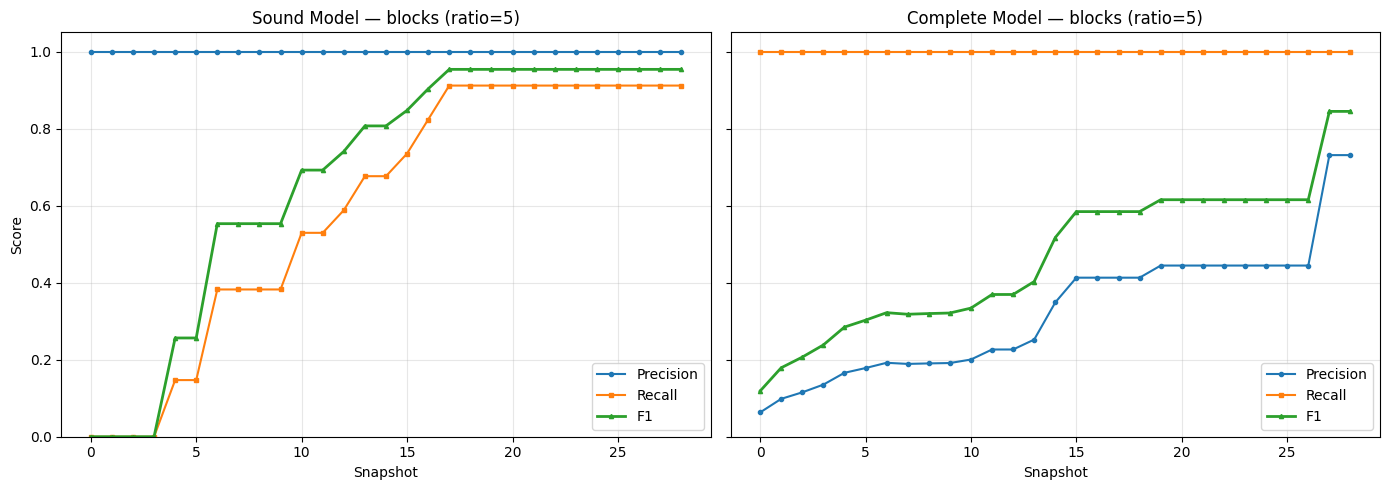

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = list(range(len(combined_results)))

ax = axes[0]
ax.plot(x, sound_precision, label="Precision", marker="o", markersize=3)
ax.plot(x, sound_recall, label="Recall", marker="s", markersize=3)
ax.plot(x, sound_results, label="F1", marker="^", markersize=3, linewidth=2)
ax.set_xlabel("Snapshot")
ax.set_ylabel("Score")
ax.set_title(f"Sound Model — {DOMAIN_NAME} (ratio={RATIO_NEG_POS})")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, complete_precision, label="Precision", marker="o", markersize=3)
ax.plot(x, complete_recall, label="Recall", marker="s", markersize=3)
ax.plot(x, complete_results, label="F1", marker="^", markersize=3, linewidth=2)
ax.set_xlabel("Snapshot")
ax.set_title(f"Complete Model — {DOMAIN_NAME} (ratio={RATIO_NEG_POS})")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Version Space Report
Summary statistics per action: number of precondition hypotheses (`n_pre`), upper bound on effect hypotheses (`n_eff = 2^|U_eff - L_eff|`), and whether the action has converged (L == U for both preconditions and effects).

In [11]:
print(f"Converged: {learner.converged}")
print(f"Collapsed actions: {learner.collapsed_actions or 'none'}")
print(f"Total demos processed: {learner.demo_count}")
print()
for action_name, stats in learner.version_space_size.items():
    print(f"  {action_name:15s} | pre={stats['n_pre']:4d} | eff≤{stats['n_eff']:6d} | converged={stats['converged']}")

Converged: False
Collapsed actions: none
Total demos processed: 198

  pickup          | pre= 320 | eff≤   128 | converged=False
  putdown         | pre= 512 | eff≤    64 | converged=False
  stack           | pre=1024 | eff≤   128 | converged=False
  unstack         | pre= 640 | eff≤   128 | converged=False


### Version Space Boundaries
Detailed view of the learned L (lower / most-specific) and U (upper / most-general) boundaries for each action:

- **L_pre** — the most specific precondition hypothesis: intersection of all positive pre-states seen. Contains the true preconditions plus any co-occurring invariants that were never contradicted.
- **U_pre** — the most general precondition hypotheses still consistent with all negatives. Multiple hypotheses may exist when the algorithm hasn't yet determined which literals are the true preconditions.
- **L_eff** — confirmed effects: literals observed in every positive post-state (union of all deltas).
- **U_eff** — possible effects: literals not yet ruled out as effects.
- **Uncertain effects** — literals in U_eff but not L_eff, i.e., effects the algorithm has not yet confirmed or eliminated.

In [12]:
for action in all_actions:
    name = action.name
    print(f"{'=' * 60}")
    print(f"Action: {name}")
    print(f"{'=' * 60}")

    # --- Preconditions ---
    L_pre_set = learner.L_pre[name]
    U_pre_set = learner.U_pre[name]
    # L_pre is a set of frozensets (each frozenset is a hypothesis);
    # U_pre likewise. Show the intersection (agreed-upon preconditions).
    print(f"\n  Preconditions (L_pre — must-have):")
    if L_pre_set:
        for hyp in sorted(L_pre_set, key=str):
            lits = sorted(hyp, key=str)
            print(f"    {{ {', '.join(str(l) for l in lits)} }}")
    else:
        print(f"    (empty)")

    print(f"\n  Preconditions (U_pre — may-have, {len(U_pre_set)} hypotheses):")
    if U_pre_set:
        for hyp in sorted(U_pre_set, key=str):
            lits = sorted(hyp, key=str)
            print(f"    {{ {', '.join(str(l) for l in lits)} }}")
    else:
        print(f"    (empty)")

    # --- Effects ---
    L_eff_set = learner.L_eff[name]
    U_eff_set = learner.U_eff[name]
    # L_eff and U_eff are each a set containing a single frozenset
    l_eff = next(iter(L_eff_set)) if L_eff_set else frozenset()
    u_eff = next(iter(U_eff_set)) if U_eff_set else frozenset()

    print(f"\n  Effects — L_eff (confirmed, {len(l_eff)} literals):")
    for lit in sorted(l_eff, key=str):
        print(f"    {lit}")

    print(f"\n  Effects — U_eff (possible, {len(u_eff)} literals):")
    for lit in sorted(u_eff, key=str):
        print(f"    {lit}")

    uncertain = u_eff - l_eff
    if uncertain:
        print(f"\n  Effects — uncertain ({len(uncertain)} literals, in U but not L):")
        for lit in sorted(uncertain, key=str):
            print(f"    {lit}")
    else:
        print(f"\n  Effects fully converged ✓")

    print()

Action: pickup

  Preconditions (L_pre — must-have):
    { arm_empty(), clear(x), on_table(x), ¬holding(x), ¬holding(y), ¬holding(z), ¬on(x, y), ¬on(x, z), ¬on(y, x), ¬on(y, z), ¬on(z, x) }

  Preconditions (U_pre — may-have, 2 hypotheses):
    { arm_empty(), clear(x), on_table(x) }
    { arm_empty(), clear(x), ¬on(x, y), ¬on(x, z) }

  Effects — L_eff (confirmed, 4 literals):
    holding(x)
    ¬arm_empty()
    ¬clear(x)
    ¬on_table(x)

  Effects — U_eff (possible, 11 literals):
    holding(x)
    ¬arm_empty()
    ¬clear(x)
    ¬holding(y)
    ¬holding(z)
    ¬on(x, y)
    ¬on(x, z)
    ¬on(y, x)
    ¬on(y, z)
    ¬on(z, x)
    ¬on_table(x)

  Effects — uncertain (7 literals, in U but not L):
    ¬holding(y)
    ¬holding(z)
    ¬on(x, y)
    ¬on(x, z)
    ¬on(y, x)
    ¬on(y, z)
    ¬on(z, x)

Action: putdown

  Preconditions (L_pre — must-have):
    { holding(x), ¬arm_empty(), ¬clear(x), ¬holding(y), ¬holding(z), ¬on(x, y), ¬on(x, z), ¬on(y, x), ¬on(z, x), ¬on_table(x) }

  Precond